In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from collections import Counter

#### Exploratory Data Analysis — Animals10 Dataset

##### 1. Dataset Overview
This dataset contains 10 classes of animals with ~26k images total.

In [2]:
# path to dataset
data_path = "classification/data/raw-img"

In [3]:
italian_to_english = {
    "cane": "dog",
    "cavallo": "horse", 
    "elefante": "elephant",
    "farfalla": "butterfly",
    "gallina": "chicken",
    "gatto": "cat",
    "mucca": "cow",
    "pecora": "sheep",
    "ragno": "spider",
    "scoiattolo": "squirrel"
}

In [4]:
# count images per class
class_counts = {}
for class_name in os.listdir(data_path):
    if os.path.isdir(os.path.join(data_path, class_name)):
        count = len(os.listdir(os.path.join(data_path, class_name)))
        english_name = italian_to_english[class_name]
        class_counts[english_name] = count

In [5]:
print(class_counts)

{'chicken': 3098, 'spider': 4821, 'cat': 1668, 'butterfly': 2112, 'cow': 1866, 'horse': 2623, 'dog': 4863, 'sheep': 1820, 'squirrel': 1862, 'elephant': 1446}


##### 2. Class Distribution
Let's visualize how many images each class has.

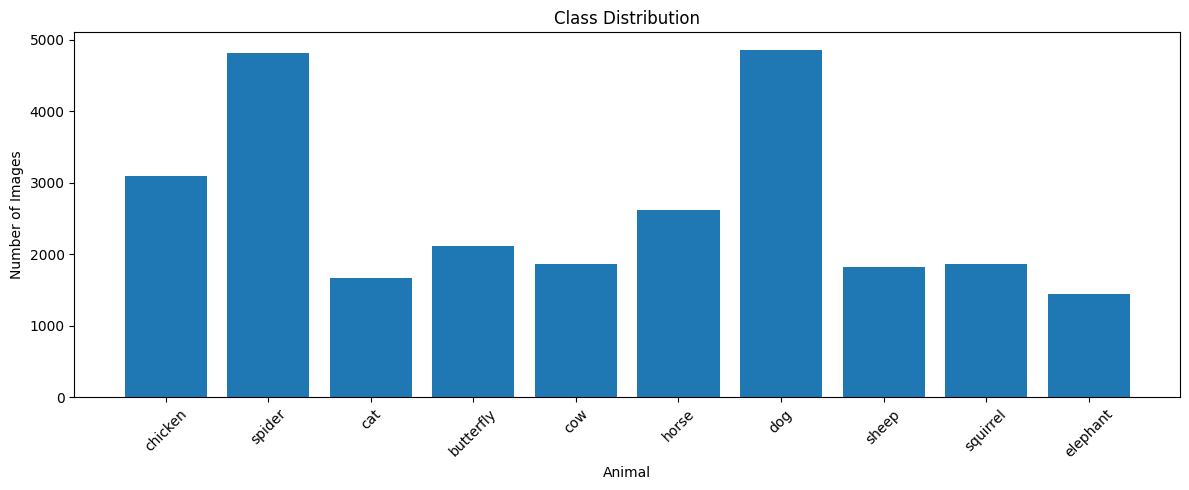

In [6]:
plt.figure(figsize=(12, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Class Distribution")
plt.xlabel("Animal")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> The dataset is imbalanced:
> - Largest classes: dog (4863) and spider (4821)
> - Smallest classes: elephant (1446) and cat (1668)

##### 3. Sample Images
Let's look at some examples from each class.

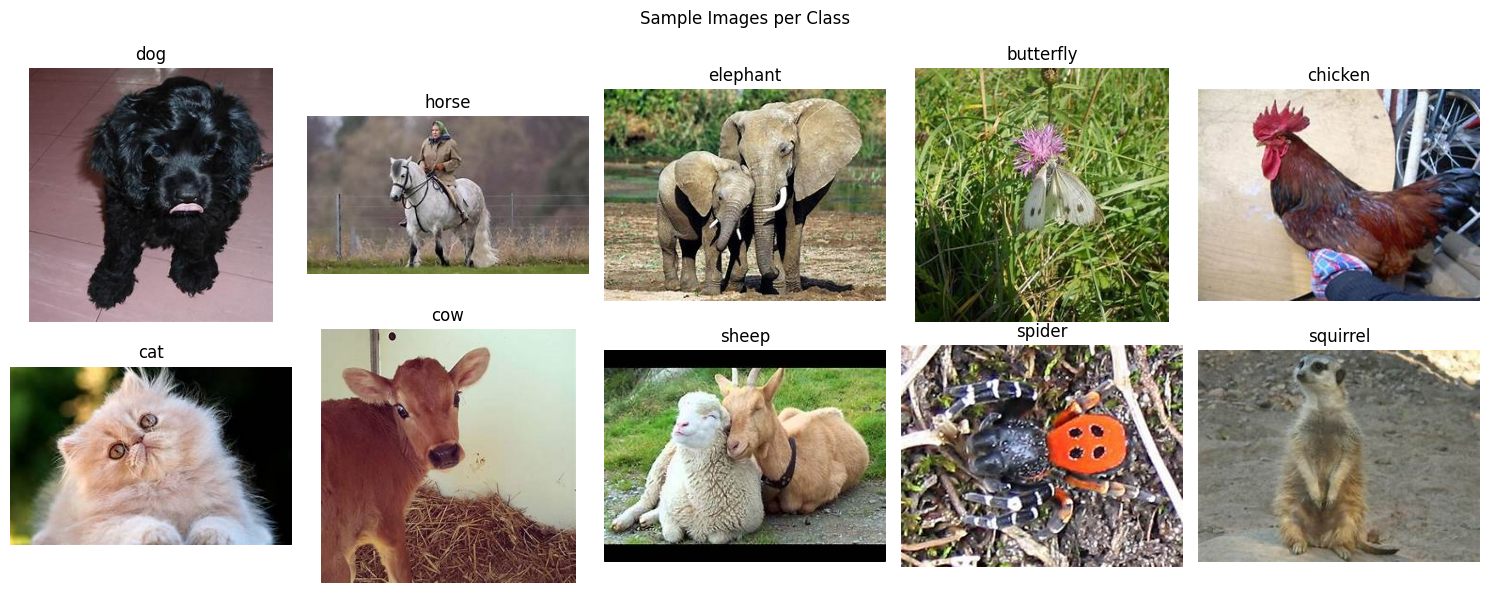

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for idx, (italian, english) in enumerate(italian_to_english.items()):
    class_path = os.path.join(data_path, italian)
    img_file = os.listdir(class_path)[0]  # перше зображення
    img = Image.open(os.path.join(class_path, img_file)).convert("RGB")
    axes[idx].imshow(img)
    axes[idx].set_title(english)
    axes[idx].axis('off')

plt.suptitle("Sample Images per Class")
plt.tight_layout()
plt.show()

> **Note:** Some images may contain incorrect labels.
> For example, the "squirrel" class contains images of meerkats

##### 4. Image Sizes
Let's check if all images have the same size.

In [9]:
sizes = []
for italian in italian_to_english.keys():
    class_path = os.path.join(data_path, italian)
    for img_file in os.listdir(class_path)[:50]:
        img_path = os.path.join(class_path, img_file)
        try:
            img = Image.open(img_path)
            sizes.append(img.size)
        except:
            pass

widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

print(f"Width:  min={min(widths)}, max={max(widths)}, mean={np.mean(widths):.0f}")
print(f"Height: min={min(heights)}, max={max(heights)}, mean={np.mean(heights):.0f}")

Width:  min=112, max=4896, mean=332
Height: min=92, max=3264, mean=259


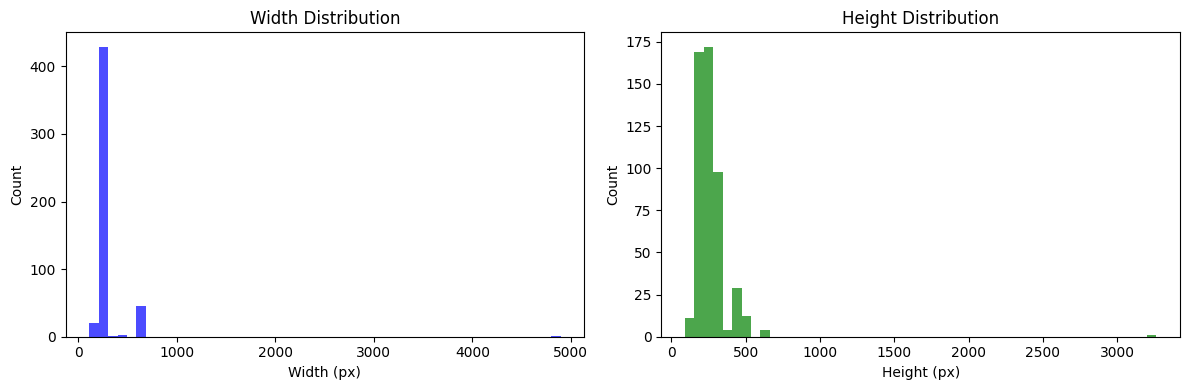

In [10]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(widths, bins=50, color='blue', alpha=0.7)
plt.title("Width Distribution")
plt.xlabel("Width (px)")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.hist(heights, bins=50, color='green', alpha=0.7)
plt.title("Height Distribution")
plt.xlabel("Height (px)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

##### 5. Conclusions

- **Total images:** 26,179 across 10 classes
- **Imbalanced dataset:** dog (4863) and spider (4821) vs elephant (1446) and cat (1668)
- **Variable image sizes:** width ranges from 112 to 4896px, height from 92 to 3264px → resizing to 224×224 is necessary
- **Label noise:** "squirrel" class contains some meerkat images
- **Preprocessing applied:** resize to 224×224, normalization with ImageNet mean/std